pySR

In [29]:
import sys
!{sys.executable} -m pip install pysr
import os
os.environ["PYTHON_JULIACALL_AUTOLOAD_IPYTHON_EXTENSION"] = "no"


# 2단계: pySR이 내부적으로 쓸 핵심 엔진(Julia) 설치 및 연결
import pysr
pysr.install()

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False

c:\Users\songa\AppData\Local\Programs\Python\Python313\Lib\site-packages\pysr\deprecated.py:10: FutureWarning: The `install` function has been removed. PySR now uses the `juliacall` package to install its dependencies automatically at import time. 
  warnings.warn(


In [30]:
import pandas as pd
df_loaded = pd.read_csv('drag_force_data.csv')
df = df_loaded.copy()

데이터셋  설정

In [31]:
FILE_PATH = 'drag_force_data.csv' 

#  [수정] 각 센서 통계량을 독립된 문자열 원소로 올바르게 분리했습니다.
TERMINAL_SET = ['X0', 'X1', 'X2', 'X3', 'X4']
FEATURES = [ 'logRe'] 
SPLIT_TARGET = 'regime'  
TARGET = 'Y' 

# function_Set
BINARY_OPERATORS = [ "*", "/"] 
UNARY_OPERATORS  = ["square"]    # 에러 방지를 위해 음수 입력이 안전한 연산자로 구성

# 다중 population을 위한 설정 
NUM_POPULATIONS = 15 
POPULATION_SIZE = 100

MAX_ITERATIONS = 40
MAX_COMPLEXITY = 10

MAX_DEPTH = 7
TARGET_FITNESS = 0.0

CONSTRAINTS= (0, 0, 0, 0, 0)

N_GROUPS = 2                     
MIN_SAMPLES_LEAF = 40

Decision tree

In [32]:
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree 

class TreeSpliter:
    def __init__(self, file_path, feature_cols, target_col):
        self.df = pd.read_csv(file_path)
        self.feature_cols = feature_cols
        self.target_col = target_col
        self.tree = None
        self.grouped_datasets = []

    def fit_and_split(self, n_groups, min_samples_leaf):
        X = self.df[self.feature_cols]
        y = self.df[self.target_col]
     
        self.tree = DecisionTreeClassifier(
            max_leaf_nodes=n_groups, 
            min_samples_leaf=min_samples_leaf, 
            random_state=42
        )
        self.tree.fit(X, y)
        
        print("decision tree 분기 기준")
        print(export_text(self.tree, feature_names=self.feature_cols))
        
        self.df['group_id'] = self.tree.apply(X)
        
        self.grouped_datasets = []
        print("그룹 분할 결과")
        for g_id in sorted(self.df['group_id'].unique()):
            group_df = self.df[self.df['group_id'] == g_id]
            X_group = group_df[TERMINAL_SET]   # SR 입력용: X0~X4만
            y_group = group_df[TARGET]       # SR 타겟용: Y
            
            self.grouped_datasets.append((X_group, y_group, g_id))
            print(f"Group {g_id} 분리 완료 (샘플 수 {len(group_df)}개)")
            
        return self.grouped_datasets

    def visualize(self):
        if self.tree is None:
            raise ValueError("먼저 fit_and_split() 메소드를 실행하여 모델을 학습")
            
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        plot_tree(
            self.tree, 
            feature_names=self.feature_cols, 
            filled=True, 
            rounded=True, 
            ax=axes[0],
            fontsize=10
        )
        axes[0].set_title("의사결정 나무 분기 구조", fontsize=14, fontweight='bold')
        
        importances = self.tree.feature_importances_
        best_feature_idx = importances.argmax()
        best_feature_name = self.feature_cols[best_feature_idx]
        
        sns.scatterplot(
            data=self.df, 
            x=best_feature_name, 
            y='Y', 
            hue='group_id', 
            palette='Set1', 
            alpha=0.8, 
            ax=axes[1]
        )
        
        thresholds = [t for t in self.tree.tree_.threshold if t != -2]
        for val in thresholds:
            axes[1].axvline(x=val, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
            
        axes[1].set_title(f"{best_feature_name} 기준 그룹 분포", fontsize=14, fontweight='bold')
        axes[1].set_xlabel(f"{best_feature_name} 값", fontsize=12)
        axes[1].set_ylabel("Y", fontsize=12)
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()

decision tree 분기 기준
|--- logRe <= -0.01
|   |--- class: laminar(Stokes)
|--- logRe >  -0.01
|   |--- class: turbulent(Newton)

그룹 분할 결과
Group 1 분리 완료 (샘플 수 66개)
Group 2 분리 완료 (샘플 수 434개)


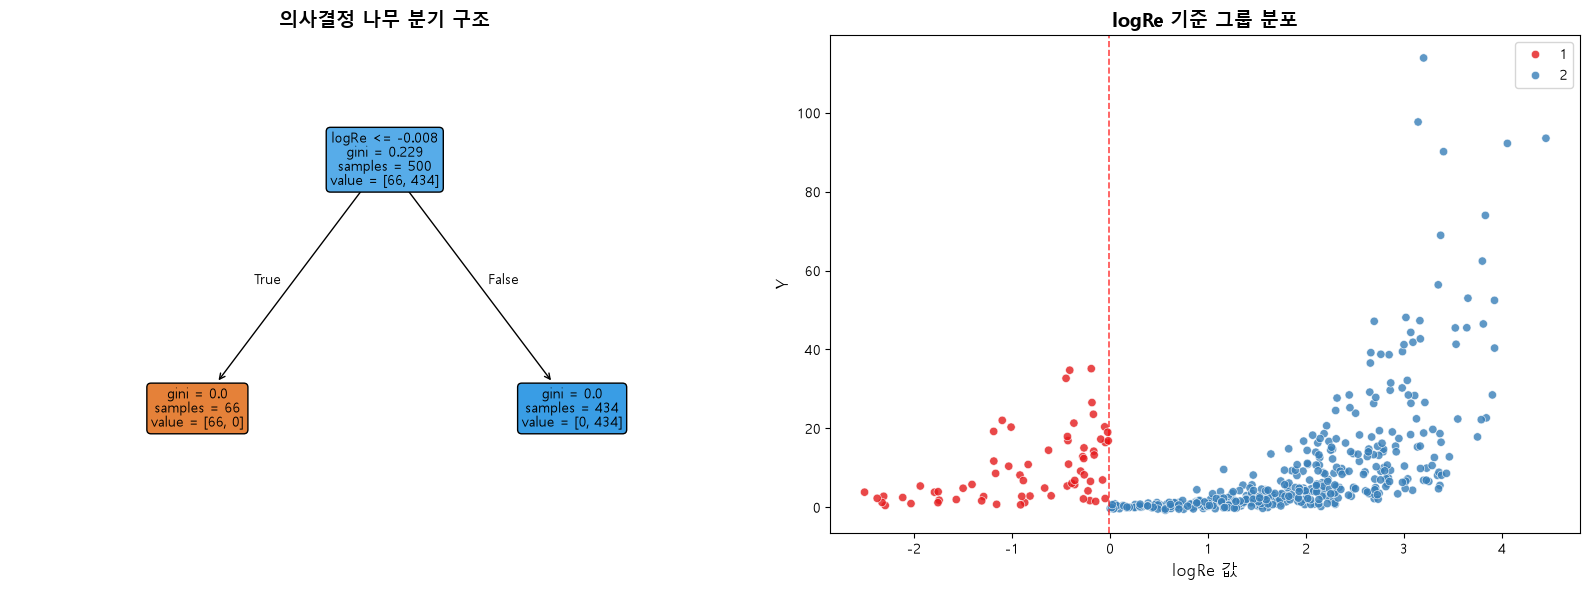

In [33]:
splitter = TreeSpliter(file_path=FILE_PATH, feature_cols=FEATURES, target_col=SPLIT_TARGET)
grouped_data = splitter.fit_and_split(n_groups=N_GROUPS, min_samples_leaf=MIN_SAMPLES_LEAF)
splitter.visualize()


In [34]:
for g_id in sorted(splitter.df['group_id'].unique()):
    subset = splitter.df[splitter.df['group_id'] == g_id]
    print(f"[Group {g_id}]  샘플수={len(subset)}")
    print(subset['regime'].value_counts())
    print(f"  Re 범위: {subset['Re'].min():.3f} ~ {subset['Re'].max():.3f}")
    print()

[Group 1]  샘플수=66
regime
laminar(Stokes)    66
Name: count, dtype: int64
  Re 범위: 0.082 ~ 0.982

[Group 2]  샘플수=434
regime
turbulent(Newton)    434
Name: count, dtype: int64
  Re 범위: 1.002 ~ 85.278



Group ID가 1, 3, 4

-노드 0(루트 노드)과 노드 2(중간 분기점)는 최종 잎 노드가 아니기 때문에 데이터 분리 결과에 존재하지 않는 것

Monotonic constraints 

In [35]:
# %%
def create_monotonic_objective(constraints, penalty_weight=0.05):
    constraints_julia = str(tuple(constraints))
    
    return f"""
    function custom_loss(tree, dataset::Dataset{{T,L}}, options) where {{T,L}}
        pred, flag = eval_tree_array(tree, dataset.X, options)
        if !flag || !all(isfinite, pred)
            return convert(L, 1e9)
        end

        base_loss = sum((dataset.y .- pred).^2) / length(dataset.y)
        if !isfinite(base_loss)
            return convert(L, 1e9)
        end

        penalty = zero(L)
        try
            _, grad, gflag = eval_grad_tree_array(tree, dataset.X, options; variable=true)
            if gflag && all(isfinite, grad)
                constraints = {constraints_julia}
                n_vars = size(grad, 1)
                n_samples = size(grad, 2)
                violation_ratio = zero(L)

                for j in 1:length(constraints)
                    if j > n_vars
                        continue
                    end
                    c = constraints[j]
                    if c == 1
                        n_violated = count(x -> x < 0, grad[j, :])
                        violation_ratio += n_violated / n_samples
                    elseif c == -1
                        n_violated = count(x -> x > 0, grad[j, :])
                        violation_ratio += n_violated / n_samples
                    end
                end
                penalty = convert(L, {penalty_weight} * violation_ratio)
            end
        catch
            # gradient 계산 실패는 무시하고 penalty=0으로 진행 (전체를 죽이지 않음)
        end

        return convert(L, base_loss * (1 + penalty))
    end
    """

공통 설정 (딕셔너리 초기화 + objective 생성)

In [36]:
import pandas as pd
from pysr import PySRRegressor

pysr_models_by_group = {}
best_equations_by_group = {}

# 🌟 먼저 penalty_weight=0 으로 "제약 없이" 정상 수식이 나오는지부터 확인하세요
dynamic_objective = create_monotonic_objective(CONSTRAINTS, penalty_weight=0.0)

In [51]:
import sympy
from pysr import PySRRegressor

# 1. 커스텀 연산자 및 SymPy 매핑 정의
UNARY_OPERATORS = [
    "safe_log(x::T) where {T} = x > 0 ? log(x) : T(NaN)",
    "safe_sqrt(x::T) where {T} = x >= 0 ? sqrt(x) : T(NaN)",
]

EXTRA_SYMPY_MAPPINGS = {
    "safe_log": lambda x: sympy.log(x),
    "safe_sqrt": lambda x: sympy.sqrt(x),
}

# 2. 복잡도(Complexity Cost) 제약 설정
# 연산자별 패널티/비용 부여 (기본값은 보통 1이며, 높을수록 해당 연산자를 억제함)
COMPLEXITY_OF_OPERATORS = {
    "safe_log": 2,   # safe_log가 쓰이면 복잡도 +2
    "safe_sqrt": 2,  # safe_sqrt가 쓰이면 복잡도 +2
    "+": 1,
    "-": 1,
    "*": 1,
    "/": 2,          # 나눗셈 남발을 막기 위해 +2 지정 예시
}

COMPLEXITY_OF_CONSTANTS = 1  # 상수(예: 3.14) 하나당 부여할 복잡도 비용 (기본값: 1)
COMPLEXITY_OF_VARIABLES = 1  # 변수(x0, x1 등) 하나당 부여할 복잡도 비용 (기본값: 1)


def run_pysr_for_group(X_group, y_group, g_id):
    print("\n" + "=" * 60)
    print(f" [Group {g_id}] 데이터에 대해 PySR 심볼릭 회귀분석을 시작합니다.")
    print(f"   - 샘플 수: {len(X_group)}개")
    print("=" * 60, flush=True)

    model = PySRRegressor(
        niterations=100,
        binary_operators=BINARY_OPERATORS,
        unary_operators=UNARY_OPERATORS,
        extra_sympy_mappings=EXTRA_SYMPY_MAPPINGS,
        
        # --- 복잡도(Complexity) 제약 파라미터 추가 ---
        complexity_of_operators=COMPLEXITY_OF_OPERATORS,
        complexity_of_constants=COMPLEXITY_OF_CONSTANTS,
        complexity_of_variables=COMPLEXITY_OF_VARIABLES,
        # ---------------------------------------------
        
        model_selection="best",
        loss_function=dynamic_objective,
        populations=NUM_POPULATIONS,
        population_size=POPULATION_SIZE,
        maxsize=MAX_COMPLEXITY,
        maxdepth=MAX_DEPTH,
        progress=False,
        verbosity=0,
        procs=0,
        parsimony=0.005,
        temp_equation_file=True,
    )
    model.fit(X_group, y_group)

    best_row = model.get_best()
    best_eq_sympy = model.sympy()

    result = {
        "equation_str": best_row["equation"],
        "sympy_format": best_eq_sympy,
        "complexity": best_row["complexity"],
        "loss": best_row["loss"],
    }

    report = (
        f" [Group {g_id}] 수식 탐색 완료!\n"
        f" 최적의 수식 (문자열): {best_row['equation']}\n"
        f" 최적의 수식 (SymPy): {best_eq_sympy}\n"
        f" 복잡도: {best_row['complexity']}, Loss: {best_row['loss']:.6f}"
    )
    print(report, flush=True)

    return model, result

In [ ]:
'''
def run_pysr_for_group(X_group, y_group, g_id):
    print("\n" + "="*60)
    print(f" [Group {g_id}] 데이터에 대해 PySR 심볼릭 회귀분석을 시작합니다.")
    print(f"   - 샘플 수: {len(X_group)}개")
    print("="*60, flush=True)

    model = PySRRegressor(
        niterations=100,
        binary_operators=BINARY_OPERATORS,
        unary_operators=UNARY_OPERATORS,
        model_selection="best",
        loss_function=dynamic_objective,
        populations=NUM_POPULATIONS,
        population_size=POPULATION_SIZE,
        maxsize=MAX_COMPLEXITY,
        maxdepth=MAX_DEPTH,
        progress=False,
        verbosity=0,          # 일단 탐색 로그를 보기 위해 1로 (디버깅 후 다시 0)
        procs=0,
        parsimony=0.005,
        temp_equation_file=True
    )
    model.fit(X_group, y_group)

    best_row = model.get_best()
    best_eq_sympy = model.sympy()

    result = {
        "equation_str": best_row['equation'],
        "sympy_format": best_eq_sympy,
        "complexity": best_row['complexity'],
        "loss": best_row['loss']
    }

    report = (
        f" [Group {g_id}] 수식 탐색 완료!\n"
        f" 최적의 수식 (문자열): {best_row['equation']}\n"
        f" 최적의 수식 (SymPy): {best_eq_sympy}\n"
        f" 복잡도: {best_row['complexity']}, Loss: {best_row['loss']:.6f}"
    )
    print(report, flush=True)

    return model, result'''

In [48]:
for X_g, y_g, gid in grouped_data:
    print(gid, len(X_g))

1 66
2 434


In [49]:
X_g, y_g, gid = grouped_data[0]
model, result = run_pysr_for_group(X_g, y_g, gid)
pysr_models_by_group[gid] = model
best_equations_by_group[gid] = result


 [Group 1] 데이터에 대해 PySR 심볼릭 회귀분석을 시작합니다.
   - 샘플 수: 66개
 [Group 1] 수식 탐색 완료!
 최적의 수식 (문자열): X3 * ((X1 * X0) * 18.888271)
 최적의 수식 (SymPy): X3*X1*X0*18.888271
 복잡도: 7, Loss: 0.208745


In [52]:
X_g, y_g, gid = grouped_data[1]
model, result = run_pysr_for_group(X_g, y_g, gid)
pysr_models_by_group[gid] = model
best_equations_by_group[gid] = result


 [Group 2] 데이터에 대해 PySR 심볼릭 회귀분석을 시작합니다.
   - 샘플 수: 434개
 [Group 2] 수식 탐색 완료!
 최적의 수식 (문자열): (X0 * (X1 * X1)) * (X0 * X4)
 최적의 수식 (SymPy): X0*X0*X1*X1*X4
 복잡도: 9, Loss: 34.671867


In [41]:
print("\n모든 트리 그룹에 대한 PySR 최적 수식")
for g_id, info in best_equations_by_group.items():
    print(f"[Group {g_id}] {info['equation_str']} | complexity={info['complexity']} | loss={info['loss']:.6f}")


모든 트리 그룹에 대한 PySR 최적 수식
[Group 1] X1 * (X0 * (X3 * 18.888227)) | complexity=7 | loss=0.208745
[Group 2] ((X2 * square(X1 * X0)) * X4) * 0.50004387 | complexity=10 | loss=0.226984


In [42]:
'''# %%
import pandas as pd
from pysr import PySRRegressor

pysr_models_by_group = {}
best_equations_by_group = {}

# 🌟 먼저 penalty_weight=0 으로 "제약 없이" 정상 수식이 나오는지부터 확인하세요
dynamic_objective = create_monotonic_objective(CONSTRAINTS, penalty_weight=0.0)

for X_group, y_group, g_id in grouped_data:
    print("\n" + "="*60)
    print(f" [Group {g_id}] 데이터에 대해 PySR 심볼릭 회귀분석을 시작합니다.")
    print(f"   - 샘플 수: {len(X_group)}개")
    print("="*60)
    
    model = PySRRegressor(
    niterations=100,
    binary_operators=BINARY_OPERATORS,
    unary_operators=UNARY_OPERATORS,
    model_selection="best",
    loss_function=dynamic_objective,
    populations=NUM_POPULATIONS,
    population_size=POPULATION_SIZE,
    maxsize=MAX_COMPLEXITY,
    maxdepth=MAX_DEPTH,
    progress=False,
    verbosity=0,          # 일단 탐색 로그를 보기 위해 1로 (디버깅 후 다시 0)
    procs=0,
    temp_equation_file=True
)
    model.fit(X_group, y_group)
    pysr_models_by_group[g_id] = model
    
    best_row = model.get_best()
    best_eq_sympy = model.sympy()
    
    best_equations_by_group[g_id] = {
        "equation_str": best_row['equation'],
        "sympy_format": best_eq_sympy,
        "complexity": best_row['complexity'],
        "loss": best_row['loss']
    }
    
    print(f" [Group {g_id}] 수식 탐색 완료!")
    print(f" 최적의 수식 (문자열): {best_row['equation']}")
    print(f" 최적의 수식 (SymPy): {best_eq_sympy}")
    print(f" 복잡도: {best_row['complexity']}, Loss: {best_row['loss']:.6f}")

print("\n모든 트리 그룹에 대한 PySR 최적 수식 탐색 완료!")'''

'# %%\nimport pandas as pd\nfrom pysr import PySRRegressor\n\npysr_models_by_group = {}\nbest_equations_by_group = {}\n\n# 🌟 먼저 penalty_weight=0 으로 "제약 없이" 정상 수식이 나오는지부터 확인하세요\ndynamic_objective = create_monotonic_objective(CONSTRAINTS, penalty_weight=0.0)\n\nfor X_group, y_group, g_id in grouped_data:\n    print("\n" + "="*60)\n    print(f" [Group {g_id}] 데이터에 대해 PySR 심볼릭 회귀분석을 시작합니다.")\n    print(f"   - 샘플 수: {len(X_group)}개")\n    print("="*60)\n\n    model = PySRRegressor(\n    niterations=100,\n    binary_operators=BINARY_OPERATORS,\n    unary_operators=UNARY_OPERATORS,\n    model_selection="best",\n    loss_function=dynamic_objective,\n    populations=NUM_POPULATIONS,\n    population_size=POPULATION_SIZE,\n    maxsize=MAX_COMPLEXITY,\n    maxdepth=MAX_DEPTH,\n    progress=False,\n    verbosity=0,          # 일단 탐색 로그를 보기 위해 1로 (디버깅 후 다시 0)\n    procs=0,\n    temp_equation_file=True\n)\n    model.fit(X_group, y_group)\n    pysr_models_by_group[g_id] = model\n\n    best_row = model.